# Comparing the simplest two shapes to detect differences by edge count distribution

In [32]:
#imports

import ecc_vr as vr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


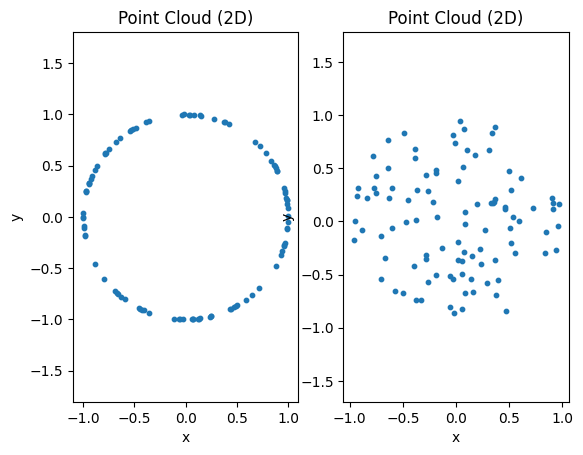

In [33]:
C = vr.sample_point_cloud(
    "circle",
    n_points = 100,
    ambient_dim= 2,
    seed = 123,
    circle_radius = 1
)

D = vr.sample_point_cloud(
    "disk",
    n_points = 100,
    ambient_dim= 2,
    seed = 123,
    circle_radius = 1
)

fig, ax = plt.subplots(1,2)

vr.plot_point_cloud_on_ax(ax[0], C, 2)
vr.plot_point_cloud_on_ax(ax[1], D, 2)



In [34]:
def edge_count_sim(
    shape: str,
    n_points: int,
    t: float,
    n_resamples: int,
    ambient_dim: int = 2,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        X = vr.sample_point_cloud(
            shape=shape,
            n_points=n_points,
            ambient_dim=ambient_dim,
            seed=sample_seed,
        )

        edge_counts[i] = vr.count_edges(X, t=t)

    return edge_counts


In [35]:
circle_counts = edge_count_sim(
    shape="circle",
    n_points=100,
    t=1.5,
    n_resamples=500,
    seed=42,
)

disk_counts = edge_count_sim(
    shape="disk",
    n_points=100,
    t=1.5,
    n_resamples=500,
    seed=43,
)


In [36]:
# standardizing distributions

def standarize(X):
    s = X.std(ddof=1)
    if s == 0:
        return np.zeros_like(X)
    return (X - X.mean()) / s

C_z = standarize(circle_counts)
D_z = standarize(disk_counts)

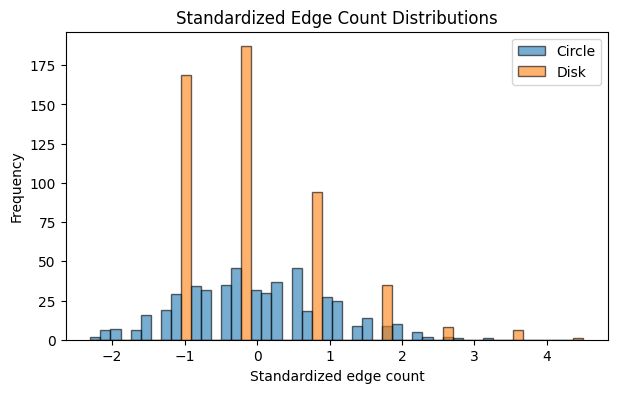

In [37]:
#histogram

bins = np.linspace(
    min(C_z.min(), D_z.min()),
    max(C_z.max(),D_z.max()),
)


plt.figure(figsize=(7, 4))
plt.hist(C_z, bins=bins, alpha=0.6, edgecolor="black", label="Circle")
plt.hist(D_z, bins=bins, alpha=0.6, edgecolor="black", label="Disk")
plt.xlabel("Standardized edge count")
plt.ylabel("Frequency")
plt.title("Standardized Edge Count Distributions")
plt.legend()
plt.show()

In [38]:
def sample_edge_count_curve(
        shape: str,
        n_points: int,
        t_grid: np.ndarray,
        ambient_dim: int = 2,
        seed: int | None = None,
) -> np.ndarray:
    
    X = vr.sample_point_cloud(
        shape = shape,
        n_points = n_points,
        ambient_dim = ambient_dim,
        seed = seed,
    )

    return np.array([vr.count_edges(X, t=float(t)) for t in t_grid], dtype = float)

def simulate_edge_count_curves(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    n_resamples: int,
    ambient_dim: int = 2,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    curves = np.empty((n_resamples, len(t_grid)), dtype=float)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        curves[i] = sample_edge_count_curve(
            shape=shape,
            n_points=n_points,
            t_grid=t_grid,
            ambient_dim=ambient_dim,
            seed=sample_seed,
        )

    return curves

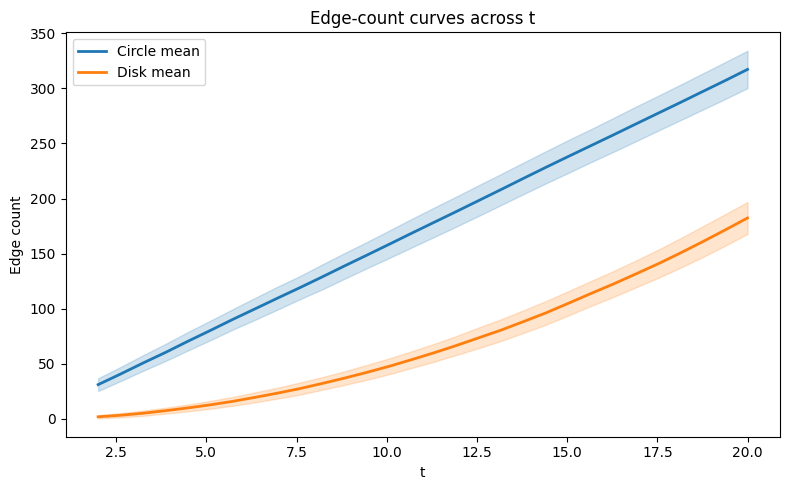

In [39]:
n_points = 100
n_resamples = 300
t_grid = np.linspace(2, 20, 30)

circle_curves = simulate_edge_count_curves(
    shape="circle",
    n_points=n_points,
    t_grid=t_grid,
    n_resamples=n_resamples,
    seed=42,
)

disk_curves = simulate_edge_count_curves(
    shape="disk",
    n_points=n_points,
    t_grid=t_grid,
    n_resamples=n_resamples,
    seed=43,
)

circle_mean = circle_curves.mean(axis=0)
circle_sd = circle_curves.std(axis=0, ddof=1)

disk_mean = disk_curves.mean(axis=0)
disk_sd = disk_curves.std(axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t_grid, circle_mean, color="tab:blue", lw=2, label="Circle mean")
ax.fill_between(
    t_grid,
    circle_mean - circle_sd,
    circle_mean + circle_sd,
    color="tab:blue",
    alpha=0.2,
)

ax.plot(t_grid, disk_mean, color="tab:orange", lw=2, label="Disk mean")
ax.fill_between(
    t_grid,
    disk_mean - disk_sd,
    disk_mean + disk_sd,
    color="tab:orange",
    alpha=0.2,
)

ax.set_xlabel("t")
ax.set_ylabel("Edge count")
ax.set_title("Edge-count curves across t")
ax.legend()
plt.tight_layout()
plt.show()

Accuracy: 1.0
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        75
        disk       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



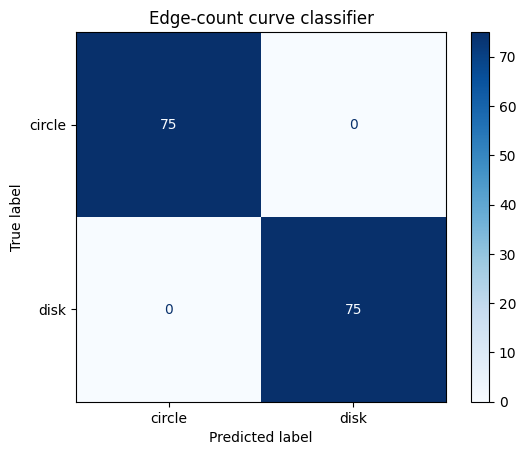

In [40]:
X = np.vstack([circle_curves, disk_curves]) #has shape (600,30) since there are 300 circle curves and 300 disk curves with each row one simulated edge count curve
y = np.array([0] * len(circle_curves) + [1] * len(disk_curves))  # 0=circle, 1=disk

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y #gives 450 training samples, 150 test samples with 75 circles and 75 disks in test set
)

clf = make_pipeline(
    StandardScaler(), #standardizes each feature column using training-set statistics
    LogisticRegression(max_iter=5000) #learns a linear decision boundary in 30-dimensional curve space
)

clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test) #train and predicts

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["circle", "disk"]))

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=["circle", "disk"], cmap="Blues"
)
plt.title("Edge-count curve classifier")
plt.show()


# Classification Process Idea

1. Clean the shape names with normalize_shape_name
2. Check the pair with validate_shape_pair
3. Compute geometric size with intrinsic_volume
4. Sample equal-size clouds with sample_equal_volume_point_cloud
5. Turn each cloud into an edge-count curve with sample_edge_count_curve_equal_volume
6. Repeat many times with simulate_edge_count_curves_equal_volume
7. Train/test the classifier with run_shape_pair_edge_curve_classifier
8. Visualize the result with plot_shape_pair_results

In [52]:
def normalize_shape_name(shape: str) -> str:
    key = shape.lower().strip()
    for ch in [" ", "-", "_", "(", ")"]:
        key = key.replace(ch, "")

    aliases = {
        "filleddisk": "disk",
        "filleddisc": "disk",
        "disc": "disk",
        "figureeight": "figure8",
        "cylinderwithcaps": "closedcylinder",
        "cylinderfilledends": "closedcylinder",
        "closed": "closedcylinder",
        "normalblob": "gaussian",
    }
    return aliases.get(key, key)

SHAPE_INFO = {
    "circle": {"intrinsic_dim": 1, "min_ambient_dim": 2},
    "figure8": {"intrinsic_dim": 1, "min_ambient_dim": 2},
    "disk": {"intrinsic_dim": 2, "min_ambient_dim": 2},
    "cylinder": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "closedcylinder": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "sphere": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "torus": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "swissroll": {"intrinsic_dim": 2, "min_ambient_dim": 3},
    "gaussian": {"intrinsic_dim": None, "min_ambient_dim": 1},
}



#returns intrinsic size of the shape using geometric formula
def intrinsic_volume(shape: str, **kwargs) -> float:
    shape = normalize_shape_name(shape)

    circle_radius = kwargs.get("circle_radius", 1.0)
    cylinder_radius = kwargs.get("cylinder_radius", 1.0)
    cylinder_height = kwargs.get("cylinder_height", 2.0)
    sphere_radius = kwargs.get("sphere_radius", 1.0)
    torus_R = kwargs.get("Torus_R", 2.0)
    torus_r = kwargs.get("Torus_r", 0.7)

    if shape == "circle":
        return 2 * np.pi * circle_radius

    if shape == "figure8":
        return 4 * np.pi * circle_radius

    if shape == "disk":
        return np.pi * circle_radius**2

    if shape == "cylinder":
        return 2 * np.pi * cylinder_radius * cylinder_height

    if shape == "closedcylinder":
        return 2 * np.pi * cylinder_radius * cylinder_height + 2 * np.pi * cylinder_radius**2

    if shape == "sphere":
        return 4 * np.pi * sphere_radius**2

    if shape == "torus":
        return 4 * np.pi**2 * torus_R * torus_r

    if shape == "swissroll":
        a = 1.5 * np.pi
        b = 4.5 * np.pi
        return (b * np.sqrt(1 + b**2) + np.arcsinh(b)) - (a * np.sqrt(1 + a**2) + np.arcsinh(a))

    raise ValueError(f"Equal-volume normalization is not implemented for shape {shape!r}.")

#checks whether two chosen shapes are allowed to be compared
def validate_shape_pair(shape1: str, shape2: str, ambient_dim: int | None = None):
    s1 = normalize_shape_name(shape1)
    s2 = normalize_shape_name(shape2)

    if s1 not in SHAPE_INFO or s2 not in SHAPE_INFO:
        raise ValueError("Unknown shape name.")

    m1 = SHAPE_INFO[s1]["intrinsic_dim"]
    m2 = SHAPE_INFO[s2]["intrinsic_dim"]

    if m1 is None or m2 is None:
        raise ValueError(
            "Gaussian / normal blob is excluded here because equal finite intrinsic volume is not defined."
        )

    if m1 != m2:
        raise ValueError(
            f"Shapes must have the same intrinsic dimension. "
            f"Got {shape1} ({m1}D) and {shape2} ({m2}D)."
        )

    min_ambient = max(
        SHAPE_INFO[s1]["min_ambient_dim"],
        SHAPE_INFO[s2]["min_ambient_dim"],
    )

    if ambient_dim is None:
        ambient_dim = min_ambient

    if ambient_dim < min_ambient:
        raise ValueError(f"ambient_dim must be at least {min_ambient} for this pair.")

    return s1, s2, m1, ambient_dim

#samples one point cloud from a shape and rescales it so its instrinsic size equals target_volume
def sample_equal_volume_point_cloud(
    shape: str,
    n_points: int,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    shape_kwargs = {} if shape_kwargs is None else dict(shape_kwargs)

    shape_key = normalize_shape_name(shape)
    m = SHAPE_INFO[shape_key]["intrinsic_dim"]

    current_volume = intrinsic_volume(shape_key, **shape_kwargs)
    scale = (target_volume / current_volume) ** (1.0 / m)

    X = vr.sample_point_cloud(
        shape=shape,
        n_points=n_points,
        ambient_dim=ambient_dim,
        seed=seed,
        **shape_kwargs,
    )

    return scale * X

#turns one sampled cloud into edge_count curve
def sample_edge_count_curve_equal_volume(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    X = sample_equal_volume_point_cloud(
        shape=shape,
        n_points=n_points,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed,
        shape_kwargs=shape_kwargs,
    )

    return np.array([vr.count_edges(X, t=float(t)) for t in t_grid], dtype=float)

#repeats previous step many times for simulation
def simulate_edge_count_curves_equal_volume(
    shape: str,
    n_points: int,
    t_grid: np.ndarray,
    n_resamples: int,
    ambient_dim: int,
    target_volume: float = 1.0,
    seed: int | None = None,
    shape_kwargs: dict | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    curves = np.empty((n_resamples, len(t_grid)), dtype=float)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        curves[i] = sample_edge_count_curve_equal_volume(
            shape=shape,
            n_points=n_points,
            t_grid=t_grid,
            ambient_dim=ambient_dim,
            target_volume=target_volume,
            seed=sample_seed,
            shape_kwargs=shape_kwargs,
        )

    return curves

""" 
1. sets default t_grid if not supplied
2. validates shape pair
3. simulates many equal-volume edge-count curves for shape1
4. simulates many equal-voluem edge-count curves for shape2
5. stacks them into one feature matrix X
6. creates labels y
    a. 0 for shape1
    b. 1 for shape2
7. splits data into training and test sets with class balance preserved
8. builds classifier pipline:
    a. StandardScaler() standardizes each t-feature using training data only
    b. LogisticRegression(max_iter=500) learns a linear separator
9.fits classifier
10. predicts on test set
11. returns a dictionary with shapes, dimensions, simulated curves, trianed classifier, accuracy, classification report, test data, predictions
"""
def run_shape_pair_edge_curve_classifier(
    shape1: str,
    shape2: str,
    n_points: int = 100,
    t_grid: np.ndarray | None = None,
    n_resamples: int = 300,
    ambient_dim: int | None = None,
    target_volume: float = 1.0,
    shape1_kwargs: dict | None = None,
    shape2_kwargs: dict | None = None,
    seed1: int = 42,
    seed2: int = 43,
    test_size: float = 0.25,
    random_state: int = 0,
):
    if t_grid is None:
        t_grid = np.linspace(2, 20, 30)

    shape1_key, shape2_key, intrinsic_dim, ambient_dim = validate_shape_pair(
        shape1, shape2, ambient_dim
    )

    curves1 = simulate_edge_count_curves_equal_volume(
        shape=shape1,
        n_points=n_points,
        t_grid=t_grid,
        n_resamples=n_resamples,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed1,
        shape_kwargs=shape1_kwargs,
    )

    curves2 = simulate_edge_count_curves_equal_volume(
        shape=shape2,
        n_points=n_points,
        t_grid=t_grid,
        n_resamples=n_resamples,
        ambient_dim=ambient_dim,
        target_volume=target_volume,
        seed=seed2,
        shape_kwargs=shape2_kwargs,
    )

    X = np.vstack([curves1, curves2])
    y = np.array([0] * len(curves1) + [1] * len(curves2))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": shape1_key,
        "shape2": shape2_key,
        "intrinsic_dim": intrinsic_dim,
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "t_grid": np.asarray(t_grid, dtype=float),
        "curves1": curves1,
        "curves2": curves2,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=[shape1_key, shape2_key],
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }


#visualizes and summarizes output of classifier function
def plot_shape_pair_results(result):
    t_grid = result["t_grid"]
    curves1 = result["curves1"]
    curves2 = result["curves2"]
    shape1 = result["shape1"]
    shape2 = result["shape2"]

    mean1 = curves1.mean(axis=0)
    sd1 = curves1.std(axis=0, ddof=1)

    mean2 = curves2.mean(axis=0)
    sd2 = curves2.std(axis=0, ddof=1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(t_grid, mean1, lw=2, label=f"{shape1} mean")
    ax[0].fill_between(t_grid, mean1 - sd1, mean1 + sd1, alpha=0.2)

    ax[0].plot(t_grid, mean2, lw=2, label=f"{shape2} mean")
    ax[0].fill_between(t_grid, mean2 - sd2, mean2 + sd2, alpha=0.2)

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Edge count")
    ax[0].set_title("Edge-count curves")
    ax[0].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=[shape1, shape2],
        cmap="Blues",
        ax=ax[1],
    )
    ax[1].set_title("Classifier confusion matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print(result["report"])


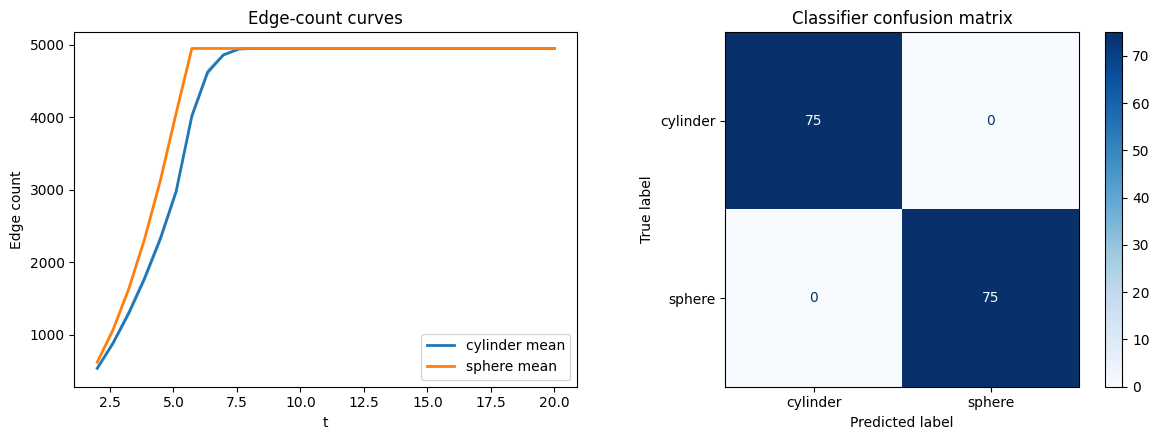

Accuracy: 1.0
              precision    recall  f1-score   support

    cylinder       1.00      1.00      1.00        75
      sphere       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



In [55]:
result = run_shape_pair_edge_curve_classifier(
    shape1="cylinder",
    shape2="sphere",
    n_points=100,
    n_resamples=300,
    t_grid=np.linspace(2, 20, 30),
    target_volume=1.0,
)
plot_shape_pair_results(result)
